# BMW Used Car Market Analysis

## Goal
Explore the BMW used car dataset using pandas and learn basic data analysis techniques.

## Technologies
- Python
- pandas
- matplotlib

### Questions answered
- Number of unique models
- Most common model
- Average price of 3 Series
- Highest individual car price
- Average mileage
- Highest average price by model
- Model with highest average MPG
- Percentage of diesel cars
- Average price by fuel type
- Top 5 models by average price

Unique models: 24
Most common model: 3 Series (2443 cars)
Average 3 Series price: £19880.86
Highest price: £123456
Average mileage: 25497 miles
Most expensive model on average: X7 (£69842.76)
Highest average mileage model: Z3 (52319 miles)
Most fuel-efficient model: i3 (470.8 mpg)
Diesel cars: 65.18%
Average price by fuel type:
fuelType
Diesel      21779.26
Electric    18466.00
Hybrid      27169.71
Other       18193.86
Petrol      24360.27
Top 5 models by average price:
model
X7          69842.76
8 Series    63997.79
M5          57760.00
i8          57012.59
X6          43838.61


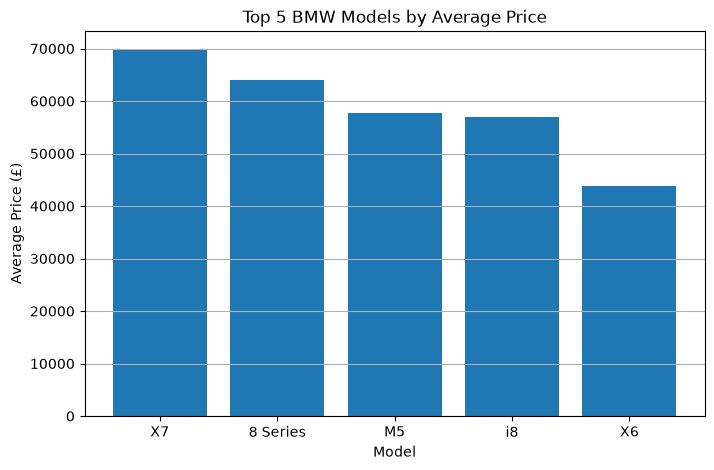

In [78]:
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load data
df = pd.read_csv("data/bmw.csv")
df["model"] = df["model"].str.strip()

# 3. Basic overview
print(f"Unique models: {df['model'].nunique()}")

model_counts = df["model"].value_counts()
print(f"Most common model: {model_counts.index[0]} ({model_counts.iloc[0]} cars)")

print(f"Average 3 Series price: £{df[df['model'] == '3 Series']['price'].mean():.2f}")
print(f"Highest price: £{df['price'].max()}")
print(f"Average mileage: {df['mileage'].mean():.0f} miles")

# 4. Grouped analysis
avg_price_by_model = df.groupby("model")["price"].mean()

print(f"Most expensive model on average: {avg_price_by_model.idxmax()} (£{avg_price_by_model.max():.2f})")

avg_mileage_by_model = df.groupby("model")["mileage"].mean()
print(f"Highest average mileage model: {avg_mileage_by_model.idxmax()} ({avg_mileage_by_model.max():.0f} miles)")

avg_mpg_by_model = df.groupby("model")["mpg"].mean()
print(f"Most fuel-efficient model: {avg_mpg_by_model.idxmax()} ({avg_mpg_by_model.max():.1f} mpg)")

# 5. Fuel type analysis
diesel_percentage = df[df["fuelType"] == "Diesel"].shape[0] / df.shape[0] * 100
print(f"Diesel cars: {diesel_percentage:.2f}%")

print("Average price by fuel type:")
fuel_prices = df.groupby("fuelType")["price"].mean().round(2)
print(fuel_prices.to_string())

# 6. Top 5 models by average price
print("Top 5 models by average price:")
model_prices = avg_price_by_model.sort_values(ascending=False).head(5).round(2)
print(model_prices.to_string())

# 7. Visualization

top5 = avg_price_by_model.sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)
plt.title("Top 5 BMW Models by Average Price")
plt.xlabel("Model")
plt.ylabel("Average Price (£)")
plt.grid(axis='y')
plt.show()

